# CMFV
Sort of like the thing in Rocket Project, but this time taking into consideration:
- Fluid dynamics
  - Head loss of valve at specific angles

I'm doing this right after the controls final so my patience for controls is out the window (overall not bad though, I'm just annoyed I think I screwed up the LQR question)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

## Modules

- [ ] **Controller**
  - $\hat{p}_1, \hat{p}_2, p_r \rightarrow \hat{p}_{err} \rightarrow \dot{\theta}_{ctrl}$
  - Not really classical controls but gonna lowk wing it
  - Could do PD
    

    **Plant (yay)**
    - Angle integrator
    - $\dot{\theta}_{ctrl} \rightarrow \theta$
    - Valve
    - $\theta, p_1, \dot{m}_1 \rightarrow p_2, \dot{m}_2$
    - Angle -> loss (assuming all geometry loss, no major loss)

    **Observers**
    - No Lutenberger or whatever just basic
    - $p_2 \rightarrow \hat{p}_2$
    - Has some amount of noise

## Step 2 ish
- Observer
  - $p_1 \rightarrow \hat{p}_1$ (maybe...)
- Plant
  - Vary upstream pressure with feedforward




````
    +
Pr ---O------| K |---->|  G  |-----------> P
      ^                              |
      |------------|  O   |<---------|

```


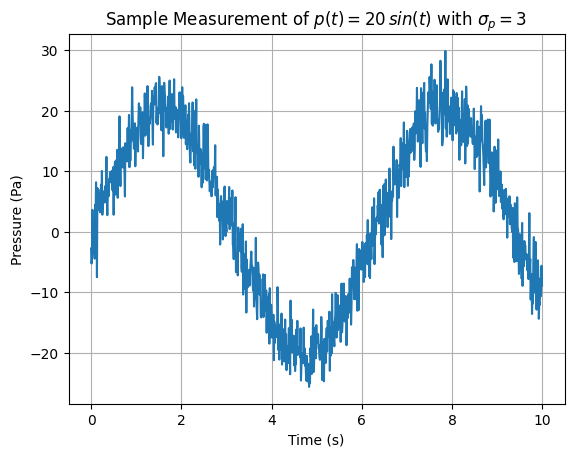

In [ ]:
class PressureTransducer:
    def __init__(self, sigma_p: float, p0 = 0):
        self.sigma_p = sigma_p
        self.p_hat = p0

    def observe(self, p):
        """Adds noise to pressure and returns"""
        self.p_hat = np.random.normal(p, self.sigma_p)
        return self.p_hat
    
dt = 0.01
ts = np.arange(1000)*dt

sigma_p = 3 # Pa

ps = 20*np.sin(ts)
ducer = PressureTransducer(sigma_p, 0)
p_hat = [ducer.observe(p) for p in ps]

plt.title(rf"Sample Measurement of $p(t) = 20\,sin(t)$ with $\sigma_p = {sigma_p}$")
plt.xlabel("Time (s)")
plt.ylabel("Pressure (Pa)")
plt.plot(ts, p_hat )
plt.grid()
plt.show()

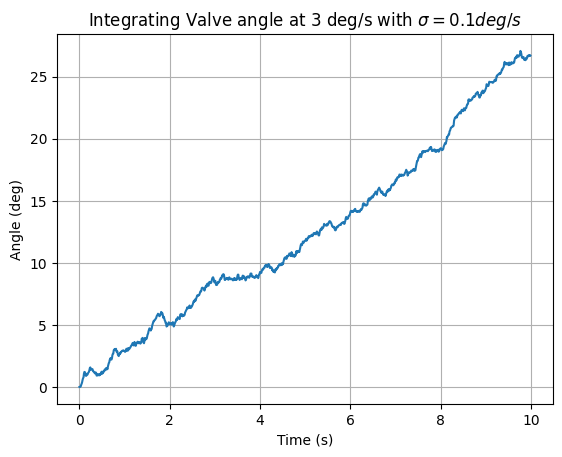

In [38]:
class ValveAngle:
    def __init__(self, dt: float, theta0 = 0.0, sigma = 0):
        """TODO: add noise"""
        self.dt = dt
        self.theta = theta0
        self.sigma = sigma

    def step(self, theta_dot: float):
        """Integrates then adds noise"""
        self.theta = self.theta + self.dt * theta_dot
        self.theta = np.random.normal(self.theta, self.sigma) # Maybe not add this?
        return self.theta
    

dt = 0.01
ts = np.arange(1000)*dt # 10 seconds

theta_dot = 3 # deg/s
sigma_angle = 0.1 # deg/s

angle = ValveAngle(dt, 0, sigma_angle)

# ducer = PressureTransducer(sigma_p, 0)
theta = [angle.step(theta_dot) for _ in ts]

title = rf"Integrating Valve angle at {theta_dot} deg/s with $\sigma = {sigma_angle} deg/s$"
plt.title(title)
plt.xlabel("Time (s)")
plt.ylabel("Angle (deg)")
plt.plot(ts, theta)
plt.grid()
plt.show()